# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
csv_url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv"
df_hotels = pd.read_csv(csv_url)
df_hotels.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. Hotel companies or investors

2. The hotel companies might want to understand hotel booking behavior to mitigate cancelations and to get costumers to feel inclined to book a stay at a specific hotel. This will limit the losses of the hotel companies and increase profits.

3. How to mitigate hotel cancelations.




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [12]:
print('DataFrame Info:')
df_hotels.info()

print('\nDataFrame Description:')
print(df_hotels.describe(include='all'))

print('\nNull Values per Column:')
print(df_hotels.isnull().sum())

print('\nNumber of Duplicate Rows:')
print(df_hotels.duplicated().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal              

### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. The country column has 266 missing values.

2. Im not sure how important country is to this data set yet but I could just delete all the rows with missing country values.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

 ADR (Average Daily Rate) - Summary Statistics:
count    9404.000000
mean       86.843614
std        53.759940
min        -6.380000
25%        45.000000
50%        71.550000
75%       120.600000
max       508.000000
Name: adr, dtype: float64


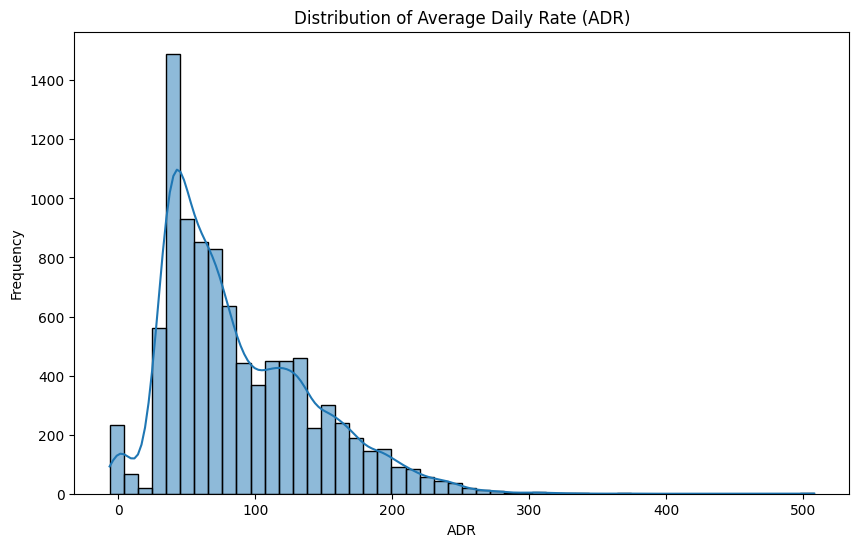

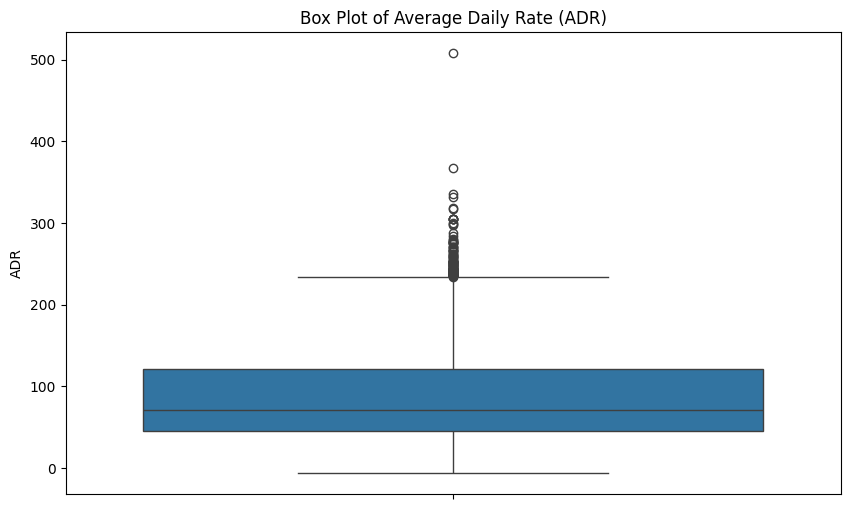


 Is Canceled - Value Counts:
is_canceled
0    7069
1    2335
Name: count, dtype: int64

 Is Canceled - Normalized Value Counts:
is_canceled
0    0.751701
1    0.248299
Name: proportion, dtype: float64


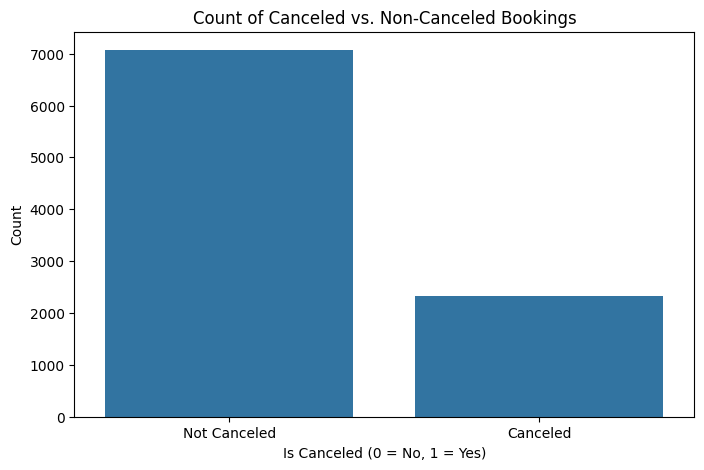


 Customer Type - Value Counts:
customer_type
Transient          7031
Transient-Party    1703
Contract            581
Group                89
Name: count, dtype: int64

 Customer Type - Normalized Value Counts:
customer_type
Transient          0.747661
Transient-Party    0.181093
Contract           0.061782
Group              0.009464
Name: proportion, dtype: float64


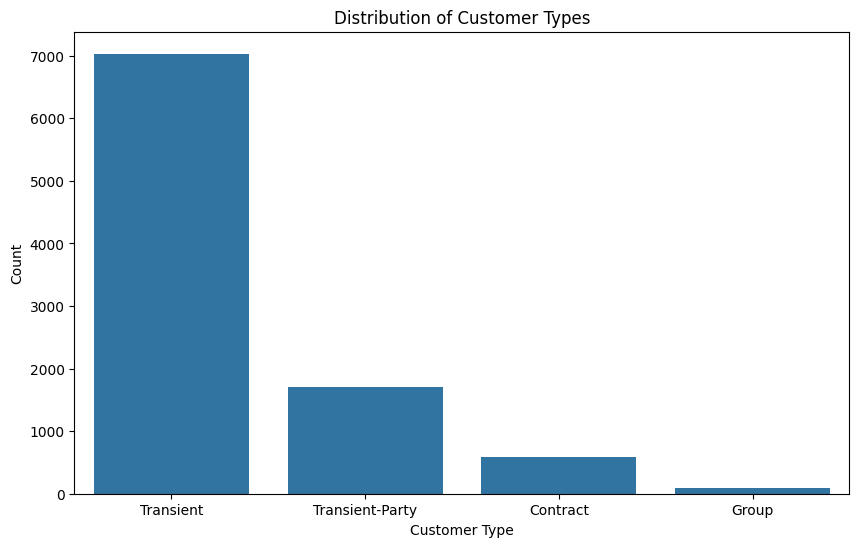

In [14]:
# --- Variable 1: Average Daily Rate (adr) ---
print(' ADR (Average Daily Rate) - Summary Statistics:')
print(df_hotels['adr'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_hotels['adr'], bins=50, kde=True)
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('ADR')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(y=df_hotels['adr'])
plt.title('Box Plot of Average Daily Rate (ADR)')
plt.ylabel('ADR')
plt.show()

# --- Variable 2: is_canceled ---
print('\n Is Canceled - Value Counts:')
print(df_hotels['is_canceled'].value_counts())
print('\n Is Canceled - Normalized Value Counts:')
print(df_hotels['is_canceled'].value_counts(normalize=True))

plt.figure(figsize=(8, 5))
sns.countplot(x='is_canceled', data=df_hotels)
plt.title('Count of Canceled vs. Non-Canceled Bookings')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

# --- Variable 3: customer_type ---
print('\n Customer Type - Value Counts:')
print(df_hotels['customer_type'].value_counts())
print('\n Customer Type - Normalized Value Counts:')
print(df_hotels['customer_type'].value_counts(normalize=True))

plt.figure(figsize=(10, 6))
sns.countplot(x='customer_type', data=df_hotels, order=df_hotels['customer_type'].value_counts().index)
plt.title('Distribution of Customer Types')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.show()


### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:
 The distribution of the Average Daily Rate.The average daily rate was approximately 86.84, with a right-skewed distribution. The minimum of −6.38 may indicate a data error or an unusual transaction.

- **Variable 2 – Summary and insights:
The proportion of canceled versus non-canceled hotel bookings. Approximately 24.83% of bookings were canceled, while 75.17% were not—meaning about one in four bookings was canceled.

- **Variable 3 – Summary and insights:
The distribution of different customer types.Transient was the most common customer type, accounting for 7,031 bookings, or approximately 74.77% of the dataset.




## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

--- Relationship 1: Lead Time vs. Is Canceled ---


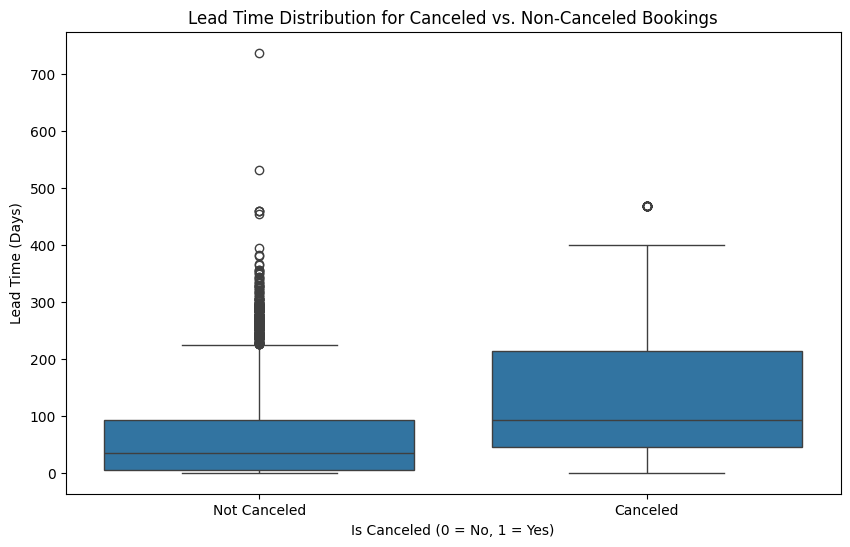


--- Relationship 2: ADR vs. Customer Type ---


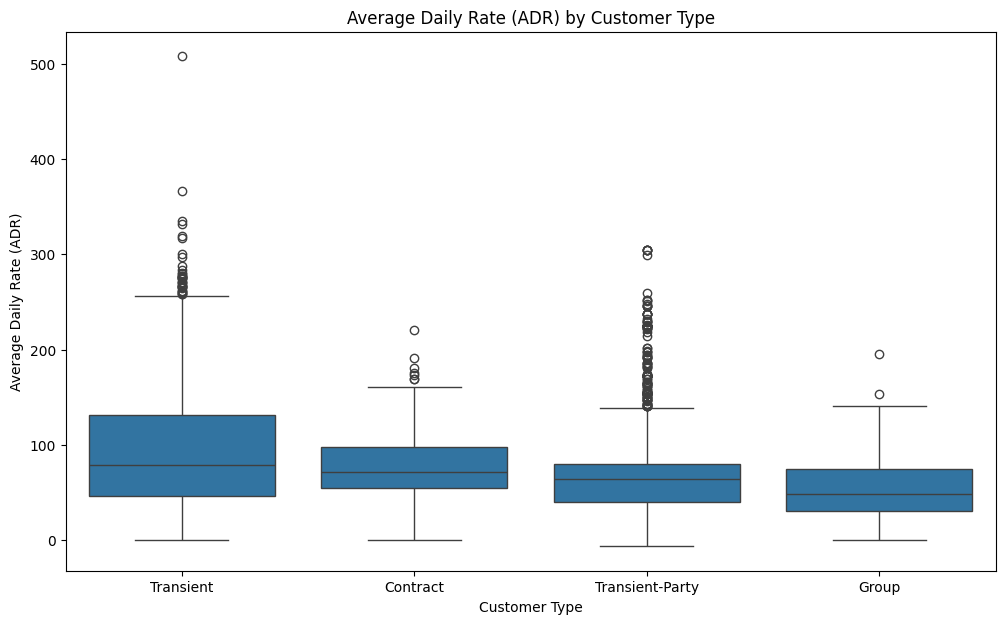

In [15]:
print('--- Relationship 1: Lead Time vs. Is Canceled ---')
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df_hotels)
plt.title('Lead Time Distribution for Canceled vs. Non-Canceled Bookings')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time (Days)')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

print('\n--- Relationship 2: ADR vs. Customer Type ---')
plt.figure(figsize=(12, 7))
sns.boxplot(x='customer_type', y='adr', data=df_hotels)
plt.title('Average Daily Rate (ADR) by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average Daily Rate (ADR)')
plt.show()

### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1 Lead Time vs. Cancellation: I compared lead times for canceled and non-canceled bookings. The analysis suggests that bookings made further in advance may be more likely to be canceled, potentially because guests have more time to change their plans.
- **Relationship 2 ADR vs. Customer Type: I compared average daily rates across different customer types. The analysis explores whether Transient customers have a wider range of rates, while Contract or Group customers have more consistent rates due to negotiated pricing.

## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. Longer lead times may be associated with a higher likelihood of cancellation. Guests who book further in advance have more time to change their plans.
2. This involves variability because cancellation behavior differs across bookings, making it difficult for hotels to anticipate occupancy and revenue.
3. Predictive analytics could use lead time and other booking characteristics to estimate the likelihood of cancellation. This would help hotels forecast occupancy and plan staffing more accurately.



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. About 25% of bookings were canceled, and longer lead times may be linked to more cancellations. ADR varied widely, including negative values, and Transient customers made up most bookings.

2. These findings connect to hotel managers’ goals of reducing cancellations, improving occupancy, and increasing revenue. Understanding booking behavior can also help managers plan staffing, while daily rates and customer types can help guide pricing and marketing decisions.

3. I would recommend considering non-refundable deposits, slightly discounted non-refundable rates, or automated reminders for bookings made far in advance to help reduce cancellations. Non refundable deposits and slightly discounted non refundable rates would be the best idea to keep customers locked into their booking.  

4. My learning outcome was to use Python to visualize large datasets so anyone could understand them. This analysis supported that goal by using Pandas, Matplotlib, and Seaborn to summarize and visualize hotel bookings. The charts and summary statistics made relationships, such as lead time versus cancellations and ADR by customer type, easier for stakeholders to understand without technical data analysis skills.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"